# House Sale Data — Visualization
Baku (Azerbaijan) real-estate listings: distribution graphs, correlation heatmap, and categorical breakdowns.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('house_sale.csv')
df.shape

(100775, 51)

## Light prep for plotting
Only minimal parsing needed to make numeric columns plottable (no modeling/cleaning beyond this).

In [2]:
# Parse area (Sahə) like "145 m²" -> 145.0
df['area_sqm'] = df['Sahə'].str.extract(r'([\d.]+)').astype(float)

# Rename key numeric columns for readability
plot_df = df.rename(columns={
    'Otaq sayı': 'rooms',
    'Kateqoriya': 'category',
    'Binanın növü': 'building_type',
    'Təmir': 'repair_status'
})

numeric_cols = ['price', 'area_sqm', 'rooms', 'views', 'lat', 'lng']
plot_df[numeric_cols].describe()

,price,area_sqm,rooms,views,lat,lng
count,1.007750e+05,100775.000000,91363.000000,100775.000000,100775.000000,100775.000000
mean,3.423557e+05,143.941045,3.133468,700.065185,40.410846,49.886371
std,2.042627e+06,1004.402694,1.372981,1680.672574,0.083193,0.265008
min,1.100000e+01,0.200000,1.000000,23.000000,32.689217,12.591688
25%,1.450000e+05,65.350000,2.000000,99.000000,40.381900,49.816470
50%,2.180000e+05,100.000000,3.000000,254.000000,40.397219,49.852867
75%,3.380000e+05,145.000000,4.000000,680.000000,40.420578,49.948995
max,6.000000e+08,200000.000000,20.000000,113458.000000,41.774687,50.341059


## 1. Distribution Graphs

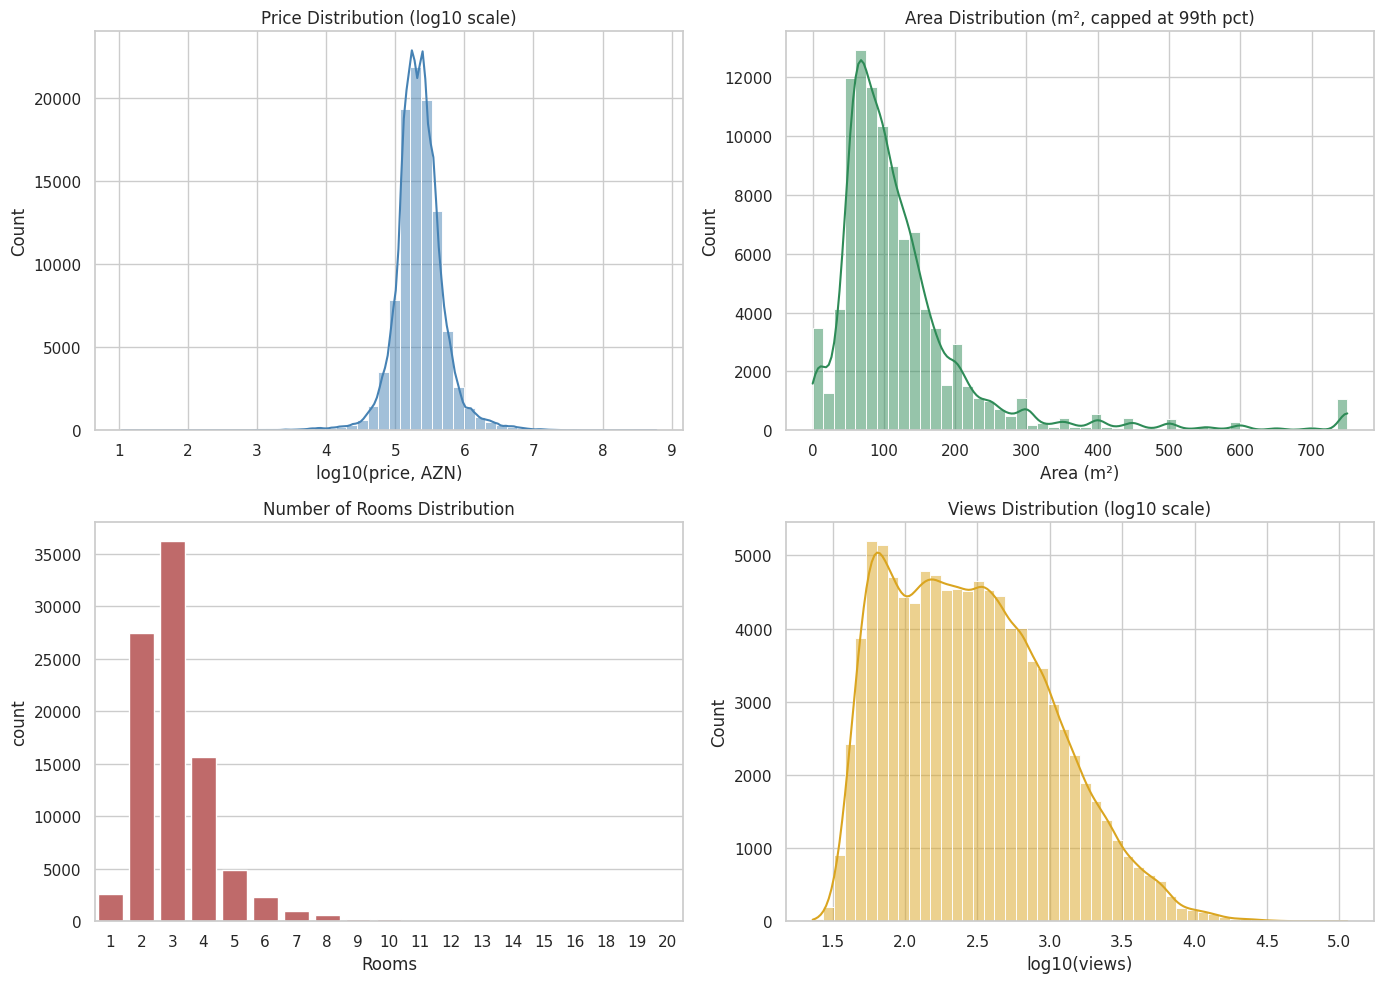

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Price distribution (log scale due to extreme outliers)
sns.histplot(plot_df.loc[plot_df['price'] > 0, 'price'].apply(np.log10), bins=50, kde=True, ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Price Distribution (log10 scale)')
axes[0,0].set_xlabel('log10(price, AZN)')

# Area distribution
sns.histplot(plot_df['area_sqm'].dropna().clip(upper=plot_df['area_sqm'].quantile(0.99)), bins=50, kde=True, ax=axes[0,1], color='seagreen')
axes[0,1].set_title('Area Distribution (m², capped at 99th pct)')
axes[0,1].set_xlabel('Area (m²)')

# Rooms distribution
sns.countplot(x=plot_df['rooms'].dropna().astype(int), ax=axes[1,0], color='indianred')
axes[1,0].set_title('Number of Rooms Distribution')
axes[1,0].set_xlabel('Rooms')

# Views distribution
sns.histplot(plot_df.loc[plot_df['views'] > 0, 'views'].apply(np.log10), bins=50, kde=True, ax=axes[1,1], color='goldenrod')
axes[1,1].set_title('Views Distribution (log10 scale)')
axes[1,1].set_xlabel('log10(views)')

plt.tight_layout()
plt.show()

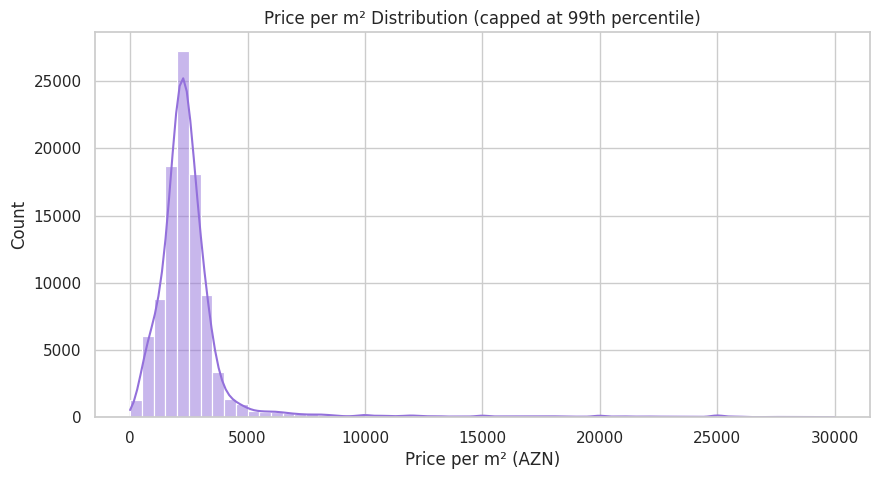

In [4]:
# Price per square meter (derived, common real-estate metric)
plot_df['price_per_sqm'] = plot_df['price'] / plot_df['area_sqm']
valid = plot_df.loc[(plot_df['price_per_sqm'] > 0) & (plot_df['price_per_sqm'] < plot_df['price_per_sqm'].quantile(0.99))]

plt.figure(figsize=(10, 5))
sns.histplot(valid['price_per_sqm'], bins=60, kde=True, color='mediumpurple')
plt.title('Price per m² Distribution (capped at 99th percentile)')
plt.xlabel('Price per m² (AZN)')
plt.show()

## 2. Correlation Heatmap

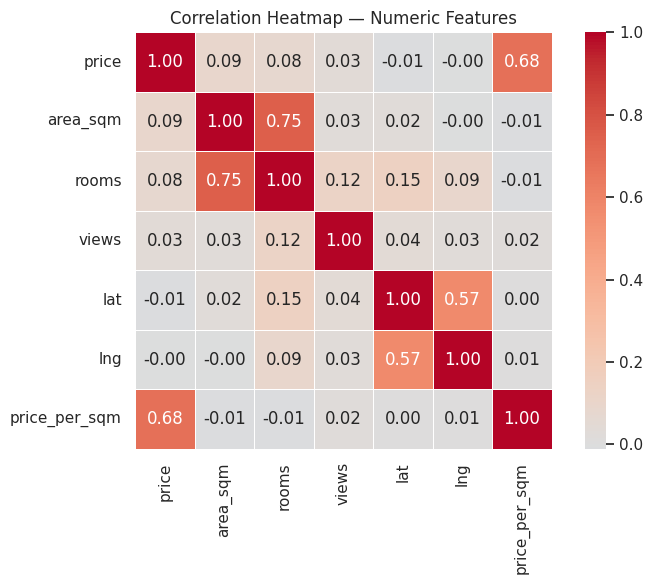

In [5]:
corr = plot_df[['price', 'area_sqm', 'rooms', 'views', 'lat', 'lng', 'price_per_sqm']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Correlation Heatmap — Numeric Features')
plt.tight_layout()
plt.show()

## 3. Categorical Breakdown

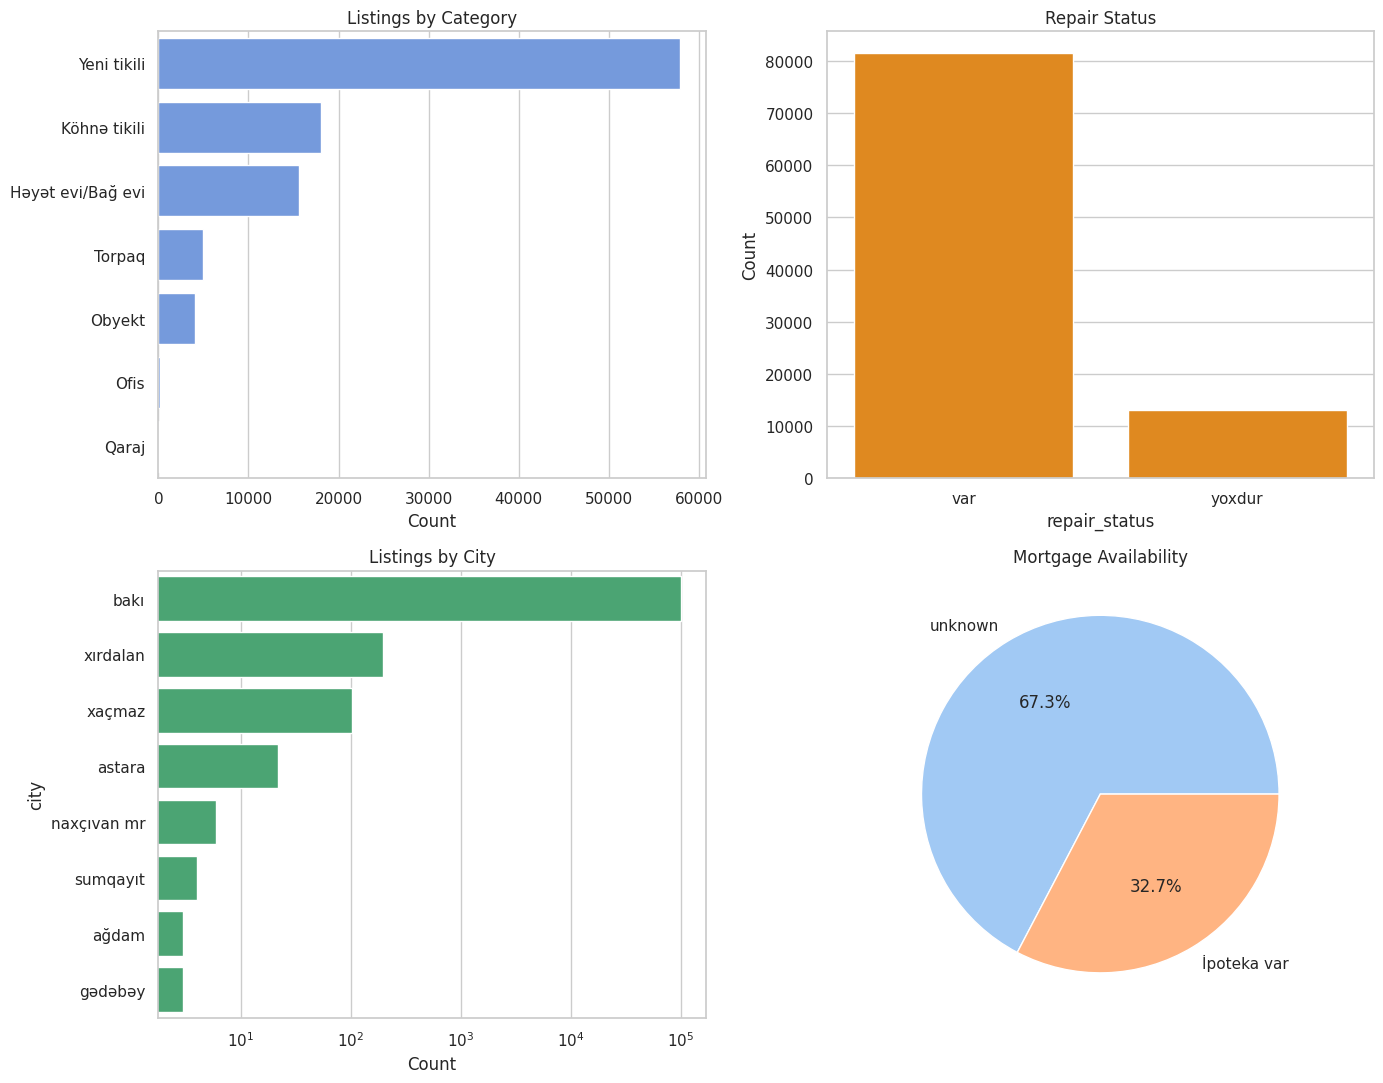

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# Category
cat_order = plot_df['category'].value_counts().index
sns.countplot(y=plot_df['category'], order=cat_order, ax=axes[0,0], color='cornflowerblue')
axes[0,0].set_title('Listings by Category')
axes[0,0].set_xlabel('Count')
axes[0,0].set_ylabel('')

# Repair status
sns.countplot(x=plot_df['repair_status'], ax=axes[0,1], color='darkorange')
axes[0,1].set_title('Repair Status')
axes[0,1].set_ylabel('Count')

# Top cities (excluding dominant Bakı to show the rest)
city_counts = plot_df['city'].value_counts()
sns.barplot(x=city_counts.values, y=city_counts.index, ax=axes[1,0], color='mediumseagreen')
axes[1,0].set_title('Listings by City')
axes[1,0].set_xlabel('Count')
axes[1,0].set_xscale('log')

# Mortgage availability
mortgage_counts = plot_df['mortgage'].fillna('unknown').value_counts()
axes[1,1].pie(mortgage_counts.values, labels=mortgage_counts.index, autopct='%1.1f%%', colors=sns.color_palette('pastel'))
axes[1,1].set_title('Mortgage Availability')

plt.tight_layout()
plt.show()

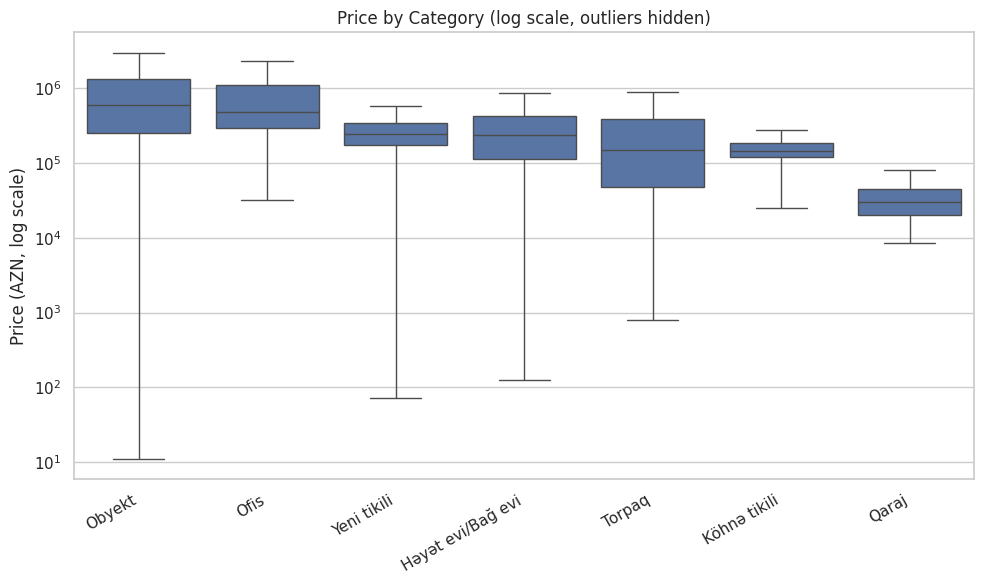

In [7]:
# Median price by category (categorical vs numeric)
plt.figure(figsize=(10, 6))
order = plot_df.groupby('category')['price'].median().sort_values(ascending=False).index
sns.boxplot(data=plot_df, x='category', y='price', order=order, showfliers=False)
plt.yscale('log')
plt.xticks(rotation=30, ha='right')
plt.title('Price by Category (log scale, outliers hidden)')
plt.ylabel('Price (AZN, log scale)')
plt.xlabel('')
plt.tight_layout()
plt.show()